In [162]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cmocean  # Paleta de cores oceânicas
# import rioxarray  # Extensão do xarray para manipulação de rasters
# import rasterio

In [182]:
# batimetria original swan
ds_bat_swan_orig = xr.open_dataset('NCfiles/Bathymetry.nc')
ds_bat_swan_orig

<xarray.Dataset> Size: 142kB
Dimensions:    (lat: 121, lon: 145)
Coordinates:
  * lat        (lat) float64 968B 33.4 33.4 33.41 33.42 ... 34.38 34.39 34.4
  * lon        (lon) float64 1kB 34.4 34.41 34.42 34.43 ... 35.59 35.6 35.6
Data variables:
    elevation  (lat, lon) float64 140kB ...
Attributes:
    Conventions:  CF-1.0
    title:        The GEBCO_2014 Grid - a continuous terrain model for oceans...
    institution:  On behalf of the General Bathymetric Chart of the Oceans (G...
    source:       The bathymetric portion of the GEBCO_2014 Grid was largely ...
    history:      This is version 20150318 of the data set. Information on th...
    references:   Information on the data set is available from the GEBCO pro...
    comment:      The data in the GEBCO_2014 Grid should not be used for navi...
    node_offset:  1
    History:      Translated to CF-1.0 Conventions by Netcdf-Java CDM (Netcdf...

In [185]:
file_path = "/mnt/c/Users/henri/OneDrive - atmosmarine.com/GEBCO/gebco_2024/gebco_2024.nc"  # Substitua pelo caminho correto
ds_gebco = xr.open_dataset(file_path)
ds_gebco_rj = ds_gebco.sel(lat=slice(-25.0, -21.0), lon=slice(-46.0, -40.0))
ds_gebco_rj.to_netcdf('NCfiles/batimetria_rj_gebco2024.nc')
ds_gebco_rj

<xarray.Dataset> Size: 3MB
Dimensions:    (lon: 1440, lat: 960)
Coordinates:
  * lon        (lon) float64 12kB -46.0 -45.99 -45.99 ... -40.01 -40.01 -40.0
  * lat        (lat) float64 8kB -25.0 -24.99 -24.99 ... -21.01 -21.01 -21.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 3MB ...
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    references:                      DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    node_offset:                     1.0

In [186]:
ds_windwave_orig = xr.open_dataset('NCfiles/windwave.nc')
ds_windwave_orig

<xarray.Dataset> Size: 547kB
Dimensions:    (longitude: 11, latitude: 10, time: 124)
Coordinates:
  * longitude  (longitude) float32 44B 34.38 34.5 34.62 ... 35.38 35.5 35.62
  * latitude   (latitude) float32 40B 34.5 34.38 34.25 ... 33.62 33.5 33.38
  * time       (time) datetime64[ns] 992B 2016-01-01 ... 2016-01-31T18:00:00
Data variables:
    u10        (time, latitude, longitude) float64 109kB ...
    v10        (time, latitude, longitude) float64 109kB ...
    swh        (time, latitude, longitude) float64 109kB ...
    mwd        (time, latitude, longitude) float64 109kB ...
    mwp        (time, latitude, longitude) float64 109kB ...
Attributes:
    Conventions:  CF-1.6
    history:      2016-04-11 10:37:29 GMT by grib_to_netcdf-1.14.5: grib_to_n...

In [195]:
# windwave

ds_wind = xr.open_dataset('/mnt/c/Users/henri/OneDrive - atmosmarine.com/database/ERA5/Brasil/ERA5_Brasil_202411/data_stream-oper_stepType-instant.nc')
ds_wave = xr.open_dataset('/mnt/c/Users/henri/OneDrive - atmosmarine.com/database/ERA5/Brasil/ERA5_Brasil_202411/data_stream-wave_stepType-instant.nc')

ds_wind = ds_wind.sel(latitude=slice(-22.0, -24.0), longitude=slice(-45.0, -41.0))
ds_wave = ds_wave.sel(latitude=slice(-22.0, -24.0), longitude=slice(-45.0, -41.0))

# Reindexando ds1 para a grade de ds2
ds_wind = ds_wind.reindex_like(ds_wave, method='nearest')

ds_windwave = xr.merge([ds_wind, ds_wave])

ds_windwave = ds_windwave.drop_vars(['expver', 'number'])

ds_windwave = ds_windwave.rename_dims({'valid_time': 'time'})

# Para o SWAN
ds_windwave1 = ds_windwave[['u10', 'v10', 'swh', 'mwd', 'mwp']]
# Inverter a ordem da latitude e Reindexar as variáveis para manter a consistência
# ds_windwave1['latitude'] = ds_windwave1['latitude'][::-1]
ds_windwave1 = ds_windwave1.reindex(latitude=ds_windwave1['latitude'])
ds_windwave1 = ds_windwave1.rename_vars({'valid_time': 'time'})
# ds_windwave1
ds_windwave1.to_netcdf('NCfiles/windwave_rj_era5_202411.nc')

In [196]:
ds_windwave1

<xarray.Dataset> Size: 654kB
Dimensions:    (time: 720, latitude: 5, longitude: 9)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2024-11-01 ... 2024-11-30T23:00:00
  * latitude   (latitude) float64 40B -22.0 -22.5 -23.0 -23.5 -24.0
  * longitude  (longitude) float64 72B -45.0 -44.5 -44.0 ... -42.0 -41.5 -41.0
Data variables:
    u10        (time, latitude, longitude) float32 130kB ...
    v10        (time, latitude, longitude) float32 130kB ...
    swh        (time, latitude, longitude) float32 130kB ...
    mwd        (time, latitude, longitude) float32 130kB ...
    mwp        (time, latitude, longitude) float32 130kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-02-23T01:34 GRIB to CDM+CF via cfgrib-0.9.1...

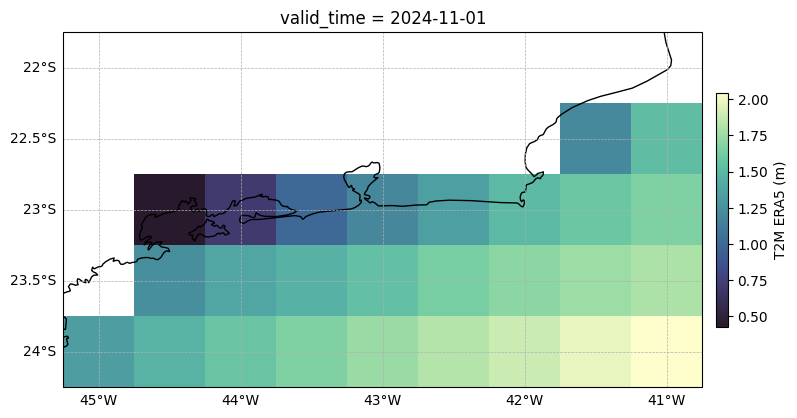

In [167]:
arr = ds_windwave.swh.isel(time=0)

fig, ax = plt.subplots(figsize=(8, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot da elevação com ajustes na barra de cores
elev_plot = arr.plot(ax=ax, cmap=cmocean.cm.deep_r,  
                            #   vmin=-50, vmax=0,
                              transform=ccrs.PlateCarree(),
                              cbar_kwargs={'label': 'T2M ERA5 (m)', 
                                           'shrink': 0.2,  # Reduz o tamanho da barra
                                           'pad': 0.02,  # Aproxima da figura
                                           'aspect': 20,  # Ajusta proporção altura/largura
                                           'fraction': 0.05,  # Reduz o espaço ocupado
                                        #    'fontsize': 8, # Diminui a fonte da legenda
                                           })  

# Adicionando camada de costa com alta resolução
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m'),
               facecolor='none', edgecolor='black', linewidth=1)

# Adicionando grade de coordenadas
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gl.right_labels = False
gl.top_labels = False

# Definir limites para a Baía de Guanabara
# ax.set_xlim(-43.5, -42.8)  # Longitude
# ax.set_ylim(-23.1, -22.6)  # Latitude

# Melhorando espaçamento do layout
fig.tight_layout()

plt.show()

In [169]:
ds.to_netcdf('NCfiles/batimeria_rj_gebco2024.nc')

In [171]:
# Definir sistema de coordenadas espaciais (GEBCO normalmente está em EPSG:4326)
# ds.rio.write_crs("EPSG:4326", inplace=True)

# Salvar como GeoTIFF
# ds.rio.to_raster("gebco_2024_rj.tif")

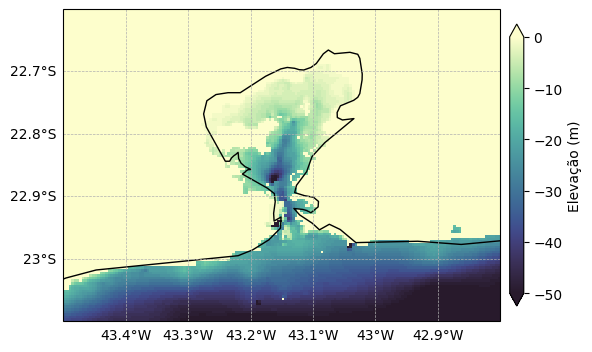

In [172]:


fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot da elevação com ajustes na barra de cores
elev_plot = ds.elevation.plot(ax=ax, cmap=cmocean.cm.deep_r,  
                              vmin=-50, vmax=0,
                              transform=ccrs.PlateCarree(),
                              cbar_kwargs={'label': 'Elevação (m)', 
                                           'shrink': 0.6,  # Reduz o tamanho da barra
                                           'pad': 0.02,  # Aproxima da figura
                                           'aspect': 20,  # Ajusta proporção altura/largura
                                           'fraction': 0.05,  # Reduz o espaço ocupado
                                        #    'fontsize': 8, # Diminui a fonte da legenda
                                           })  

# Adicionando camada de costa com alta resolução
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m'),
               facecolor='none', edgecolor='black', linewidth=1)

# Adicionando grade de coordenadas
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gl.right_labels = False
gl.top_labels = False

# Definir limites para a Baía de Guanabara
ax.set_xlim(-43.5, -42.8)  # Longitude
ax.set_ylim(-23.1, -22.6)  # Latitude

# Melhorando espaçamento do layout
fig.tight_layout()

plt.show()

In [174]:
from pyproj import Proj, transform

# Definir o sistema de coordenadas geográficas (WGS84) e UTM (zona apropriada)
proj_wgs84 = Proj(init='epsg:4326')  # WGS84
proj_utm = Proj(init='epsg:32723')  # UTM Zona 23S (exemplo, pode variar dependendo da região)

# Coordenadas de Latitude/Longitude (batimetria)
lat_min, lon_min = -24.0, -45.0
lat_max, lon_max = -22.0, -41.0

# Convertendo as coordenadas
x_min, y_min = transform(proj_wgs84, proj_utm, lon_min, lat_min)
x_max, y_max = transform(proj_wgs84, proj_utm, lon_max, lat_max)

print(f'Canto inferior esquerdo: X={x_min}, Y={y_min}')
print(f'Canto superior direito: X={x_max}, Y={y_max}')


/mnt/c/Users/henri/git/SWAN-MAT/RJ/venv/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/mnt/c/Users/henri/git/SWAN-MAT/RJ/venv/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_40406/2813201613.py:12: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-

Canto inferior esquerdo: X=500000.0, Y=7345773.461558865
Canto superior direito: X=913126.4360078112, Y=7561764.851260755
